In [81]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score

In [82]:
# Organize the excel file in a dataframe
df = pd.read_excel("Concrete_Data.xls")

# Seperate the target variable (Concrete compressive strength) from the rest "predicting" attributes
X = df.drop(columns=['Concrete compressive strength(MPa, megapascals) '], axis=1)
# Target variable
y= df['Concrete compressive strength(MPa, megapascals) '].values

# Split data in training and test tests
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 
# Standardize features
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

# Implement linear regression fitting the training data
linreg = LinearRegression() # Model initialized with no learn coefficients yet
linreg.fit(X_train_std, y_train) # Model is being trained

w = linreg.coef_
w0 = linreg.intercept_

print("\nOptimal Coefficients (w*): \n")
for name, value in zip(X.columns, w):
    print(f"{name:25s} : {value:.4f}")
print("\nIntercept (w0):", w0)
print("\nMatrix equation: ŷ = Xw + w0")

equation = "ŷ = {:.3f}".format(w0)
for coef, name in zip(w, X.columns):
    equation += " + ({:.3f} × {})".format(coef, name)

print("\nLearned linear regression equation:\n \n", equation)

# Prediction values from the test data
y_pred = linreg.predict(X_test_std)

# Square Root of Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("\nRMSE :", rmse, "MPa")


Optimal Coefficients (w*): 

Cement (component 1)(kg in a m^3 mixture) : 12.7865
Blast Furnace Slag (component 2)(kg in a m^3 mixture) : 9.4329
Fly Ash (component 3)(kg in a m^3 mixture) : 5.2556
Water  (component 4)(kg in a m^3 mixture) : -2.8921
Superplasticizer (component 5)(kg in a m^3 mixture) : 1.8411
Coarse Aggregate  (component 6)(kg in a m^3 mixture) : 1.4003
Fine Aggregate (component 7)(kg in a m^3 mixture) : 1.9474
Age (day)                 : 7.0378

Intercept (w0): 35.857718068042345

Matrix equation: ŷ = Xw + w0

Learned linear regression equation:
 
 ŷ = 35.858 + (12.787 × Cement (component 1)(kg in a m^3 mixture)) + (9.433 × Blast Furnace Slag (component 2)(kg in a m^3 mixture)) + (5.256 × Fly Ash (component 3)(kg in a m^3 mixture)) + (-2.892 × Water  (component 4)(kg in a m^3 mixture)) + (1.841 × Superplasticizer (component 5)(kg in a m^3 mixture)) + (1.400 × Coarse Aggregate  (component 6)(kg in a m^3 mixture)) + (1.947 × Fine Aggregate (component 7)(kg in a m^3 mixtu

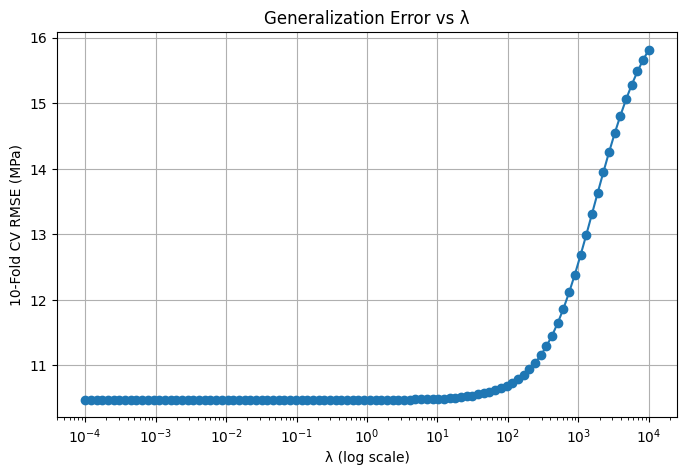

Optimal λ: 1.32194

RMSE for optimal λ (1.32194): 10.477 MPa

Optimal Coefficients (w*):

Cement (component 1)(kg in a m^3 mixture) : 12.2805
Blast Furnace Slag (component 2)(kg in a m^3 mixture) : 8.7291
Fly Ash (component 3)(kg in a m^3 mixture) : 5.4234
Water  (component 4)(kg in a m^3 mixture) : -3.3626
Superplasticizer (component 5)(kg in a m^3 mixture) : 1.7388
Coarse Aggregate  (component 6)(kg in a m^3 mixture) : 1.2444
Fine Aggregate (component 7)(kg in a m^3 mixture) : 1.4124
Age (day)                 : 7.1921

Intercept (w0): 35.8178


In [83]:
# λ values range
lambdas = np.logspace(-4, 4, 100)

# 10-Fold Cross Validation 
tenfold = KFold(n_splits=10, shuffle=True, random_state=42)

mse_scores = []

# Pipeline creation to include scaling within each fold in order to avoid data leakage 
for l in lambdas:
    ridge_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=l))
    ])
    
    # Cross-validation returns negative MSE 
    neg_mse = cross_val_score(ridge_pipeline, X, y, cv=tenfold, scoring='neg_mean_squared_error')
    mse_scores.append(-neg_mse.mean())

rmse_scores = np.sqrt(mse_scores)

# Plot generalization error vs λ
plt.figure(figsize=(8,5))
plt.semilogx(lambdas, rmse_scores, marker='o')
plt.xlabel("λ (log scale)")
plt.ylabel("10-Fold CV RMSE (MPa)")
plt.title("Generalization Error vs λ")
plt.grid(True)
plt.show()

optimal_lambda = lambdas[np.argmin(mse_scores)]
print(f"Optimal λ: {optimal_lambda:.5f}")

# Train final model on standardized full data 
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=optimal_lambda))
])

neg_mse_opt = cross_val_score(final_pipeline, X, y, cv=tenfold, scoring='neg_mean_squared_error')
rmse_opt = np.sqrt(-neg_mse_opt.mean())

print(f"\nRMSE for optimal λ ({optimal_lambda:.5f}): {rmse_opt:.3f} MPa")

final_pipeline.fit(X, y)

ridge_final = final_pipeline.named_steps['ridge']
w = ridge_final.coef_
w0 = ridge_final.intercept_

print("\nOptimal Coefficients (w*):\n")
for name, value in zip(X.columns, w):
    print(f"{name:25s} : {value:.4f}")

print(f"\nIntercept (w0): {w0:.4f}")